# Assignment 1 - Lama Aldossary - 2230006612

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load Dataset
df = pd.read_csv('movies.csv')
df.head()

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
0,1,Might toward capital,Comedy,2003,28-09-2003,China,58,7865,10596
1,2,He however experience,Comedy,1988,14-02-1988,USA,44,1708,220
2,3,Star responsibility politics,Comedy,1971,02-11-1971,USA,55,4678,7805
3,4,Exactly live,Comedy,1998,06-08-1998,USA,87,2467,1751
4,5,Focus improve especially,Documentary,2021,17-12-2021,India,67,5555,697


### Check Missing values

In [4]:
print(df.isna())

     MovieID  Title  Genre  ReleaseYear  ReleaseDate  Country  \
0      False  False  False        False        False    False   
1      False  False  False        False        False    False   
2      False  False  False        False        False    False   
3      False  False  False        False        False    False   
4      False  False  False        False        False    False   
..       ...    ...    ...          ...          ...      ...   
995    False  False  False        False        False    False   
996    False  False  False        False        False    False   
997    False  False  False        False        False    False   
998    False  False  False        False        False    False   
999    False  False  False        False        False    False   

     RottenTomatoesScore  NumVotesIMDb  NumVotesRT  
0                  False         False       False  
1                  False         False       False  
2                  False         False       False  
3      

In [5]:
print(df.isna().sum())

MovieID                0
Title                  0
Genre                  0
ReleaseYear            0
ReleaseDate            0
Country                0
RottenTomatoesScore    0
NumVotesIMDb           0
NumVotesRT             0
dtype: int64


### check duplicates

In [6]:
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### number of rows and columns

In [7]:

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1000, 9) 

number of rows:  1000
number of columns:  9


### columns data type

In [8]:
df.dtypes

MovieID                 int64
Title                  object
Genre                  object
ReleaseYear             int64
ReleaseDate            object
Country                object
RottenTomatoesScore     int64
NumVotesIMDb            int64
NumVotesRT              int64
dtype: object

In [ ]:
# Convert ReleaseDate to datetime format
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'], errors='coerce',dayfirst=True)

df.dtypes

MovieID                         int64
Title                          object
Genre                          object
ReleaseYear                     int64
ReleaseDate            datetime64[ns]
Country                        object
RottenTomatoesScore             int64
NumVotesIMDb                    int64
NumVotesRT                      int64
dtype: object

In [10]:
df.describe(include='all')

,MovieID,Title,Genre,ReleaseYear,ReleaseDate,Country,RottenTomatoesScore,NumVotesIMDb,NumVotesRT
count,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,943,8,NaN,NaN,10,NaN,NaN,NaN
top,NaN,Model western,Drama,NaN,NaN,USA,NaN,NaN,NaN
freq,NaN,3,249,NaN,NaN,723,NaN,NaN,NaN
mean,500.500000,NaN,NaN,1997.188000,1997-09-08 19:17:45.600000,NaN,64.795000,7993.563000,2415.274000
min,1.000000,NaN,NaN,1950.000000,1950-03-28 00:00:00,NaN,2.000000,100.000000,50.000000
25%,250.750000,NaN,NaN,1984.000000,1984-12-15 12:00:00,NaN,54.000000,1134.000000,127.000000
50%,500.500000,NaN,NaN,2000.000000,2000-02-20 00:00:00,NaN,64.500000,2978.500000,450.000000
75%,750.250000,NaN,NaN,2013.000000,2013-09-28 00:00:00,NaN,77.000000,7773.500000,1525.500000
max,1000.000000,NaN,NaN,2025.000000,2025-12-27 00:00:00,NaN,100.000000,293890.000000,175570.000000


## Descriptive summary statistics

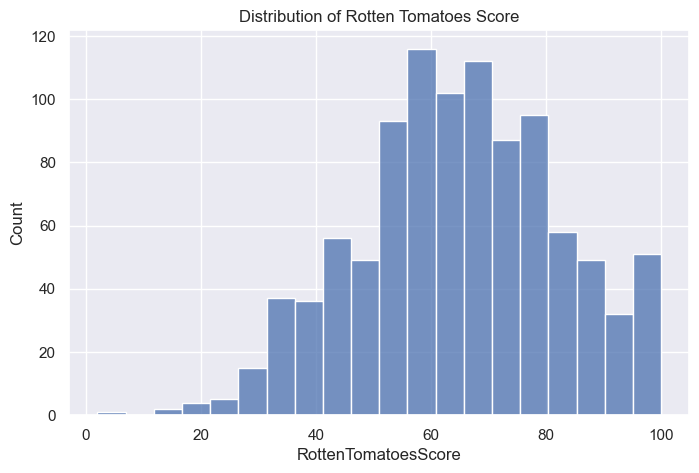

In [11]:
# Distribution of Rotten Tomatoes Score، which is a measure of the quality of the movie.
# The histogram shows that most movies have a score between 50 and 80, with a few outliers having very high or very low scores.
plt.figure(figsize=(8,5))
sns.histplot(df['RottenTomatoesScore'], bins=20)
plt.title("Distribution of Rotten Tomatoes Score")
plt.show()



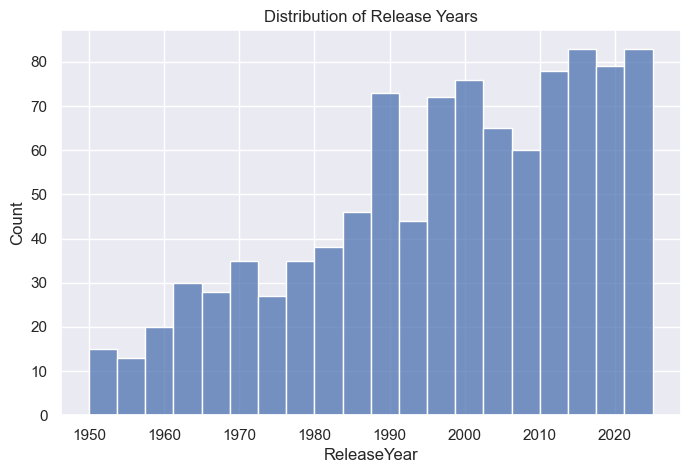

In [ ]:
# Distribution of Release Years, which shows the distribution of the years in which the movies were released.
# The histogram indicates that most movies in the dataset were released between 2000 and 2020, with a peak around 2010. 
plt.figure(figsize=(8,5))
sns.histplot(df['ReleaseYear'], bins=20)
plt.title("Distribution of Release Years")
plt.show()

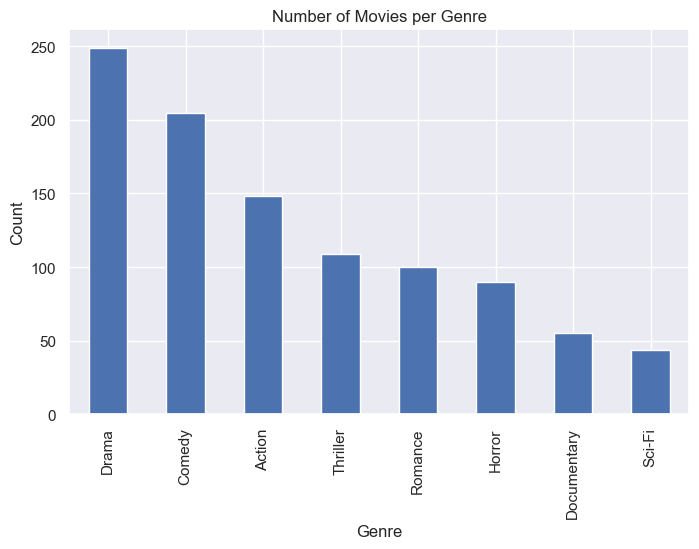

In [ ]:
# Distribution of Genres, which shows the number of movies in each genre.
# The bar chart indicates that Drama is the most common genre, followed by Comedy and Action.
plt.figure(figsize=(8,5))
df['Genre'].value_counts().plot(kind='bar')
plt.title("Number of Movies per Genre")
plt.ylabel("Count")
plt.show()

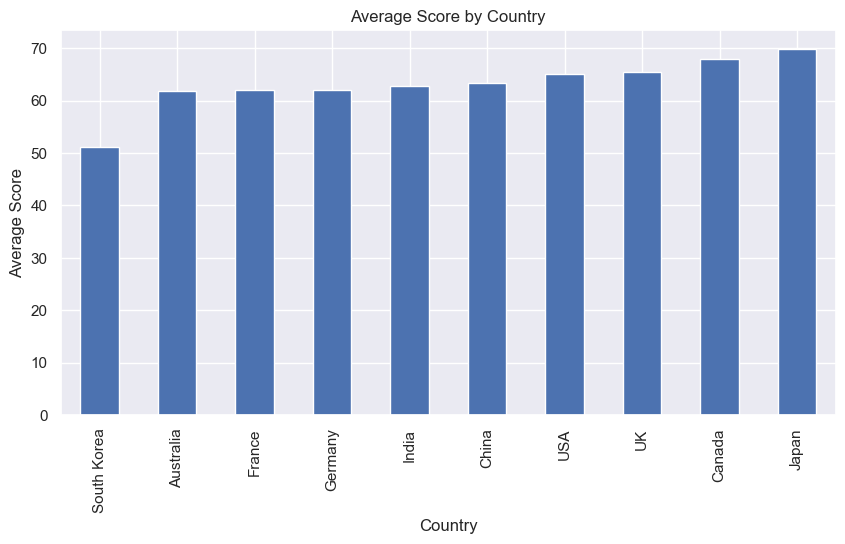

In [25]:
# Average Score by Country, which shows the average Rotten Tomatoes Score for movies from each country.
# The bar chart indicates that movies from countries like Canada and Japan tend to have higher average scores, while movies from countries like South Korea have lower average scores on Rotten Tomatoes.
country_avg = df.groupby('Country')['RottenTomatoesScore'].mean()

plt.figure(figsize=(10,5))
country_avg.sort_values().plot(kind='bar')
plt.title("Average Score by Country")
plt.ylabel("Average Score")
plt.show()

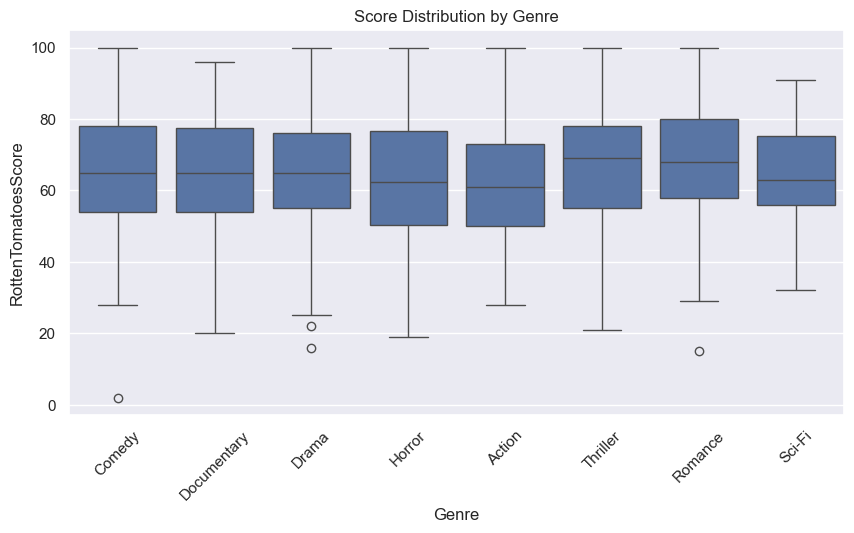

In [ ]:
# Score by Genre, which shows the total Rotten Tomatoes Score for movies in each genre. 
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='RottenTomatoesScore', data=df)
plt.xticks(rotation=45)
plt.title("Score Distribution by Genre")
plt.show()



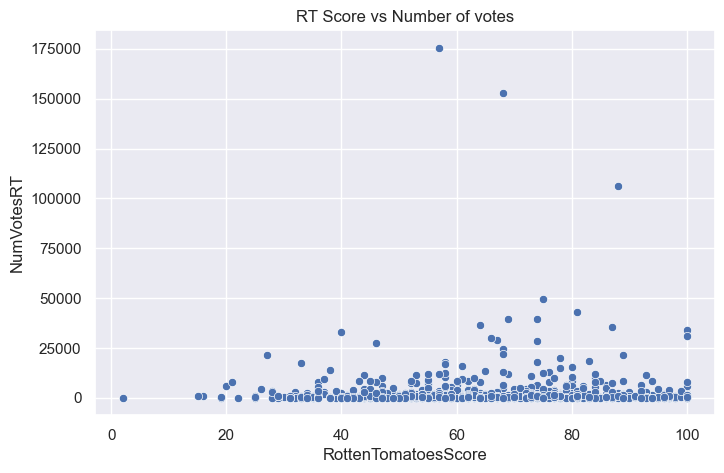

In [15]:
# RT Score vs Number of votes, which shows the relationship between the Rotten Tomatoes Score and the number of votes a movie has received on Rotten Tomatoes. 
# The scatter plot indicates that there's a positive correlation between them, meaning that movies with higher have more votes. However, there are also some outliers, such as movies with high scores but relatively few votes, and movies with low scores but many votes.
plt.figure(figsize=(8,5))
sns.scatterplot(x='RottenTomatoesScore', y='NumVotesRT', data=df)
plt.title("RT Score vs Number of votes")
plt.show()

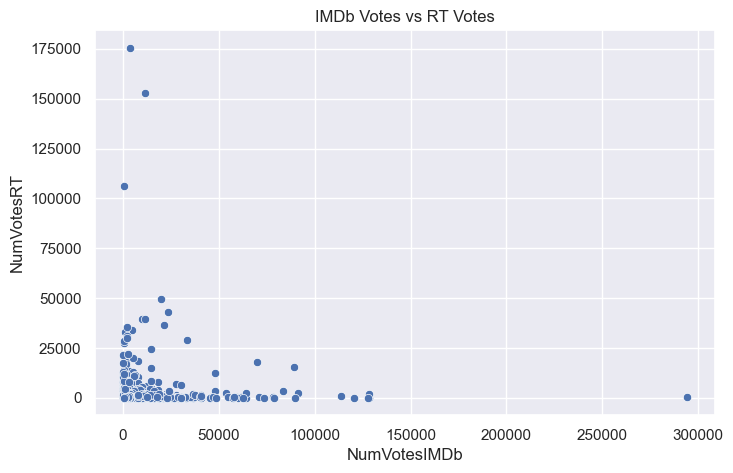

In [ ]:
# IMDb Votes vs RT Votes, which shows the relationship between the number of votes a movie has received on IMDb and Rotten Tomatoes. 
# The scatter plot indicates that there's a positive correlation between them. Movies that have received a high number of votes on IMDb also tend to have received a high number of votes on Rotten Tomatoes, and vice versa. However, there are some outliers.
plt.figure(figsize=(8,5))
sns.scatterplot(x='NumVotesIMDb', y='NumVotesRT', data=df)
plt.title("IMDb Votes vs RT Votes")
plt.show()

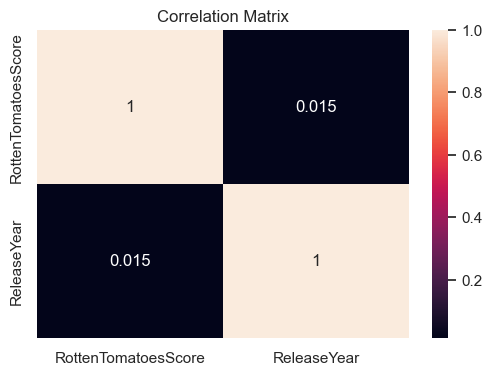

In [ ]:
# Correlation Matrix, which shows the correlation between the Rotten Tomatoes Score and the Release Year of the movies. 
# The heatmap indicates that there's a weak positive correlation between them, so movies released in recent years have slightly higher Rotten Tomatoes Scores compared to older movies.
plt.figure(figsize=(6,4))
sns.heatmap(df[['RottenTomatoesScore', 'ReleaseYear']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

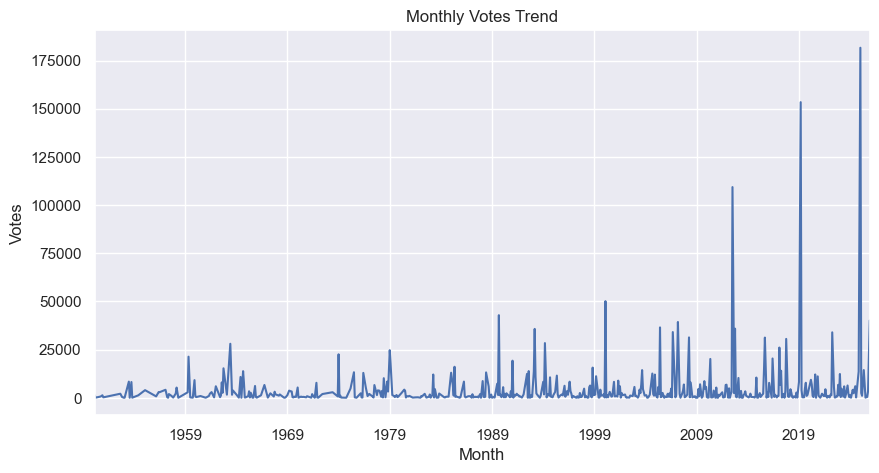

In [17]:
# Monthly Votes Trend, which shows the total number of votes on Rotten Tomatoes for movies released each month.
df['Month'] = df['ReleaseDate'].dt.to_period('M')

monthly_votes = df.groupby('Month')['NumVotesRT'].sum()

plt.figure(figsize=(10,5))
monthly_votes.plot()
plt.title("Monthly Votes Trend")
plt.ylabel("Votes")
plt.show()